In [1]:
import pandas as pd
import numpy as np
import json
import yaml
import torch
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML, Image, Markdown
from sklearn.metrics import classification_report, confusion_matrix
import sys

sys.path.append('../')
from src.models.lstm_classifier import LSTMClassifier

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 8)
pd.set_option('display.max_columns', None)

## 1. Selección Automática del Mejor Experimento

In [2]:
EXPERIMENTS_DIR = Path('../experiments')
CLASS_NAMES = ['Normal', 'Robbery']

# Cargar métricas de todos los experimentos
all_metrics = []

for exp_dir in sorted(EXPERIMENTS_DIR.iterdir()):
    if not exp_dir.is_dir():
        continue
    
    exp_name = exp_dir.name
    metrics_path = exp_dir / 'results' / 'tables' / 'lstm_final_metrics.json'
    preds_path = exp_dir / 'results' / 'tables' / 'lstm_test_predictions.json'
    
    if metrics_path.exists() and preds_path.exists():
        try:
            with open(metrics_path, 'r') as f:
                final_metrics = json.load(f)
            
            with open(preds_path, 'r') as f:
                test_predictions = json.load(f)
            
            y_true = test_predictions['labels']
            y_pred = test_predictions['preds']
            
            report_dict = classification_report(y_true, y_pred, target_names=CLASS_NAMES, output_dict=True)
            robbery_metrics = report_dict.get('Robbery', {})
            
            all_metrics.append({
                'experiment': exp_name,
                'f1_robbery': robbery_metrics.get('f1-score', 0.0),
                'recall_robbery': robbery_metrics.get('recall', 0.0),
                'auc': final_metrics.get('test_metrics', {}).get('auc', 0.0)
            })
        except Exception as e:
            print(f"Error cargando {exp_name}: {e}")

# Ordenar por F1 (Robbery), luego Recall, luego AUC
df_metrics = pd.DataFrame(all_metrics)
df_metrics = df_metrics.sort_values(by=['f1_robbery', 'recall_robbery', 'auc'], ascending=False)

# Seleccionar el mejor experimento
BEST_EXPERIMENT = df_metrics.iloc[0]['experiment']
BEST_EXP_DIR = EXPERIMENTS_DIR / BEST_EXPERIMENT

display(Markdown(f"""
### Mejor Experimento Seleccionado: **`{BEST_EXPERIMENT}`**

**Métricas:**
- F1-Score (Robbery): {df_metrics.iloc[0]['f1_robbery']:.4f}
- Recall (Robbery): {df_metrics.iloc[0]['recall_robbery']:.4f}
- AUC (Test): {df_metrics.iloc[0]['auc']:.4f}
"""))

print(f"\nDirectorio del experimento: {BEST_EXP_DIR.resolve()}")


### Mejor Experimento Seleccionado: **`exp_12`**

**Métricas:**
- F1-Score (Robbery): 0.8852
- Recall (Robbery): 0.8438
- AUC (Test): 0.9303



Directorio del experimento: D:\Dataset\experiments\exp_12


## 2. Configuración del Experimento

In [3]:
config_path = BEST_EXP_DIR / 'config_run.yml'

if config_path.exists():
    with open(config_path, 'r') as f:
        config = yaml.safe_load(f)
    
    display(Markdown("### Configuración Completa del Experimento"))
    
    # Mostrar configuración organizada
    for section, params in config.items():
        display(Markdown(f"#### {section.upper()}"))
        if isinstance(params, dict):
            df_config = pd.DataFrame(list(params.items()), columns=['Parámetro', 'Valor'])
            display(df_config)
        else:
            print(f"{section}: {params}")
        print()
else:
    print("No se encontró archivo de configuración.")

### Configuración Completa del Experimento

#### RANDOM_SEED

random_seed: 42



#### EXPERIMENT

,Parámetro,Valor
0,name,exp_12
1,base_dir,../experiments


...

,Parámetro,Valor
0,epochs,60
1,patience,10


#### OPTUNA_SEARCH

,Parámetro,Valor
0,n_trials,100
1,results_csv_name,optuna_lstm_trials.csv


#### MODEL_ARTIFACTS

,Parámetro,Valor
0,models_subdir,results/models
1,final_model_name,best_lstm_model.pth
2,final_metrics_name,lstm_final_metrics.json
3,training_history_name,lstm_training_history.json
4,test_predictions_name,lstm_test_predictions.json
5,plots_subdir,results/plots


## 3. Búsqueda de Hiperparámetros con Optuna

### 3.1 Resultados de Optuna

### Resumen de Búsqueda de Hiperparámetros


- **Total de trials:** 100
- **Trials completados:** 100
- **Trials podados:** 0
- **Mejor valor (val_loss):** 0.446287
    

### Top 10 Mejores Trials

,number,value,params_hidden_size,params_num_layers,params_bidirectional,params_dropout_fc,params_lr,params_weight_decay,params_batch_size
4,4,0.446287,256,1,True,0.59,0.000738,0.000122,32
7,7,0.462334,192,2,True,0.26,0.000883,0.000324,64
98,98,0.465013,64,1,True,0.40,0.001448,0.000225,64
95,95,0.470985,64,1,True,0.41,0.000751,0.000169,64
81,81,0.475674,256,1,True,0.27,0.000830,0.000333,64
42,42,0.476208,256,2,True,0.26,0.000953,0.000320,64
60,60,0.488101,64,1,True,0.24,0.000636,0.000173,64
93,93,0.489175,64,1,True,0.24,0.000749,0.000301,64
86,86,0.489225,96,1,True,0.24,0.000909,0.000456,16
45,45,0.491578,256,1,True,0.33,0.000843,0.000326,64


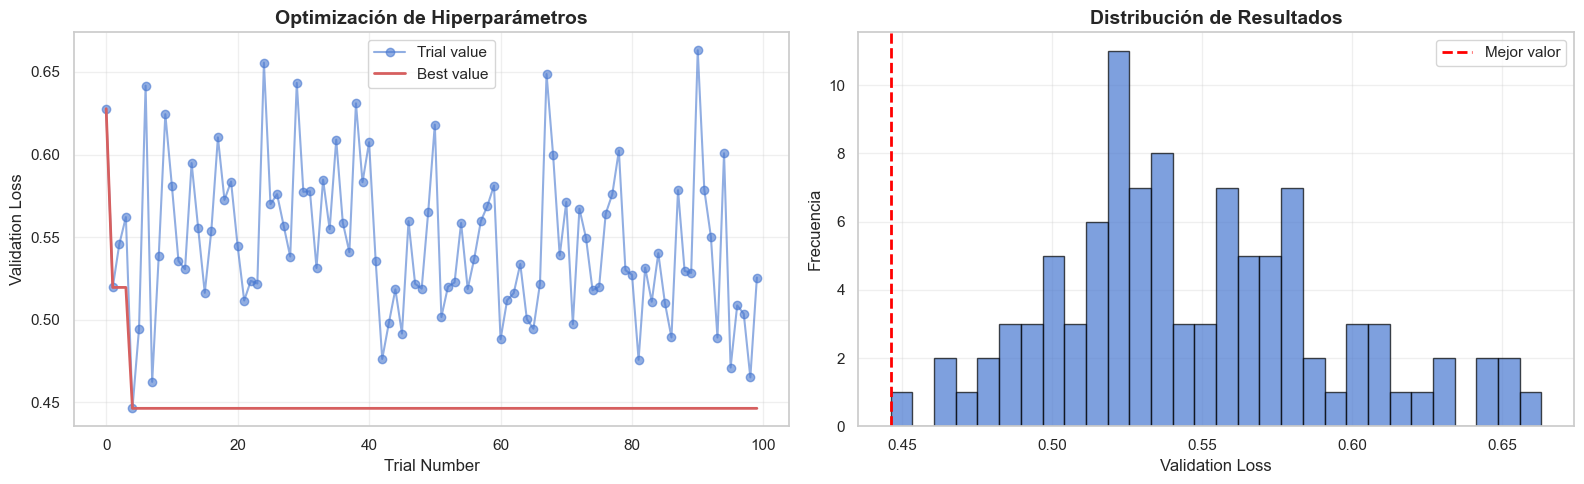

In [4]:
optuna_results_path = BEST_EXP_DIR / 'results' / 'tables' / 'optuna_lstm_trials.csv'

if optuna_results_path.exists():
    df_optuna = pd.read_csv(optuna_results_path)
    
    display(Markdown(f"### Resumen de Búsqueda de Hiperparámetros"))
    display(Markdown(f"""
- **Total de trials:** {len(df_optuna)}
- **Trials completados:** {len(df_optuna[df_optuna['state'] == 'COMPLETE'])}
- **Trials podados:** {len(df_optuna[df_optuna['state'] == 'PRUNED'])}
- **Mejor valor (val_loss):** {df_optuna['value'].min():.6f}
    """))
    
    # Top 10 mejores trials
    display(Markdown("### Top 10 Mejores Trials"))
    top_trials = df_optuna.nsmallest(10, 'value')[[
        'number', 'value', 'params_hidden_size', 'params_num_layers', 
        'params_bidirectional', 'params_dropout_fc', 'params_lr', 
        'params_weight_decay', 'params_batch_size'
    ]]
    display(top_trials.style.format({
        'value': '{:.6f}',
        'params_lr': '{:.6f}',
        'params_weight_decay': '{:.6f}',
        'params_dropout_fc': '{:.2f}'
    }).background_gradient(cmap='Greens_r', subset=['value']))
    
    # Visualización: Evolución del mejor valor
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # Gráfico 1: Historia de optimización
    completed_trials = df_optuna[df_optuna['state'] == 'COMPLETE']
    axes[0].plot(completed_trials['number'], completed_trials['value'], 'o-', alpha=0.6, label='Trial value')
    axes[0].plot(completed_trials['number'], completed_trials['value'].cummin(), 'r-', linewidth=2, label='Best value')
    axes[0].set_xlabel('Trial Number', fontsize=12)
    axes[0].set_ylabel('Validation Loss', fontsize=12)
    axes[0].set_title('Optimización de Hiperparámetros', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    #Gráfico 2: Distribución de valores
    axes[1].hist(completed_trials['value'], bins=30, edgecolor='black', alpha=0.7)
    axes[1].axvline(completed_trials['value'].min(), color='red', linestyle='--', linewidth=2, label='Mejor valor')
    axes[1].set_xlabel('Validation Loss', fontsize=12)
    axes[1].set_ylabel('Frecuencia', fontsize=12)
    axes[1].set_title('Distribución de Resultados', fontsize=14, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("No se encontró archivo de resultados de Optuna.")

### 3.2 Mejores Hiperparámetros Encontrados

In [5]:
metrics_path = BEST_EXP_DIR / 'results' / 'tables' / 'lstm_final_metrics.json'

if metrics_path.exists():
    with open(metrics_path, 'r') as f:
        final_metrics = json.load(f)
    
    best_hyperparams = final_metrics.get('best_hyperparameters', {})
    
    display(Markdown("### Mejor Combinación de Hiperparámetros (Optuna)"))
    df_best_params = pd.DataFrame(list(best_hyperparams.items()), columns=['Hiperparámetro', 'Valor'])
    display(df_best_params.style.set_properties(**{'font-weight': 'bold'}))
    
    display(Markdown(f"""
**Métricas del mejor trial:**
- Validation Loss: {final_metrics.get('best_validation_loss', 'N/A'):.6f}
- Validation AUC: {final_metrics.get('best_validation_auc', 'N/A'):.4f}
- Mejor Epoch: {final_metrics.get('best_epoch', 'N/A')}
    """))
else:
    print("No se encontró archivo de métricas finales.")

### Mejor Combinación de Hiperparámetros (Optuna)

,Hiperparámetro,Valor
0,hidden_size,256
1,num_layers,1
2,bidirectional,True
3,lr,0.000738
4,weight_decay,0.000122
5,batch_size,32
6,dropout_fc,0.594755



**Métricas del mejor trial:**
- Validation Loss: 0.446287
- Validation AUC: 0.8784
- Mejor Epoch: 9
    

## 4. Entrenamiento del Modelo Final

### 4.1 Historial de Entrenamiento

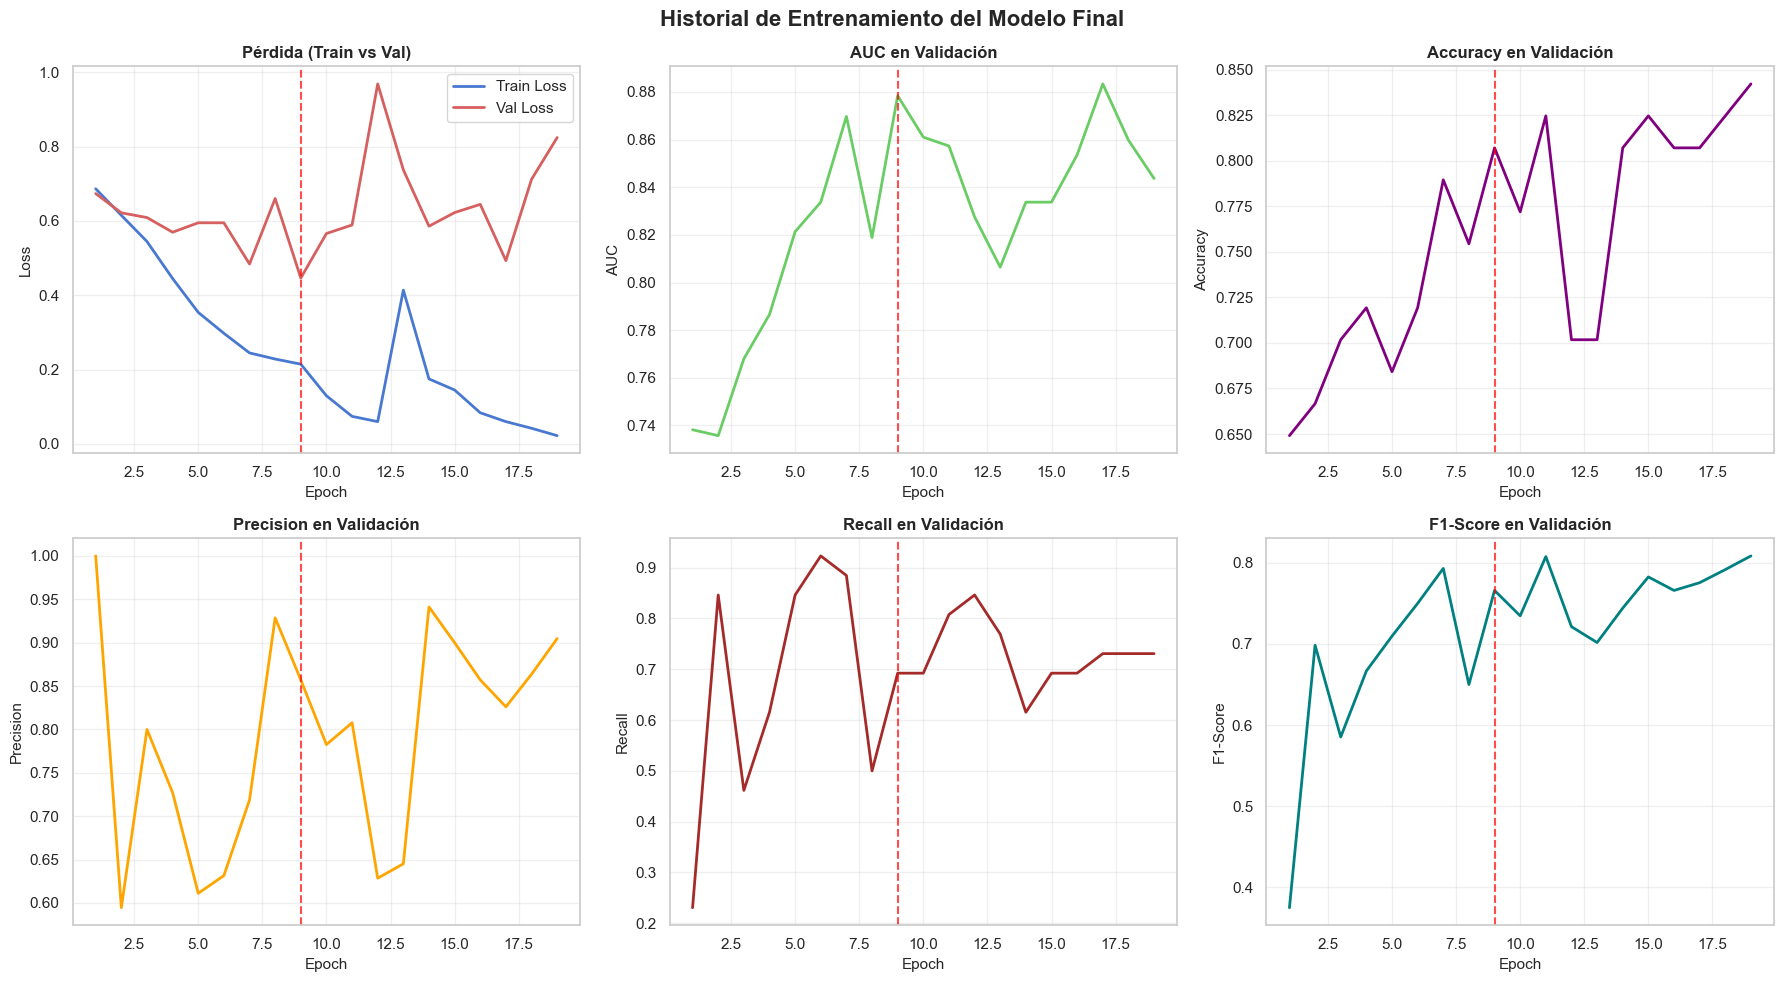


**Resumen del Entrenamiento:**
- Total de epochs ejecutados: 19
- Mejor epoch: 9
- Mejor val_loss: 0.446287
- Mejor val_auc: 0.8834
    

In [6]:
history_path = BEST_EXP_DIR / 'results' / 'tables' / 'lstm_training_history.json'

if history_path.exists():
    with open(history_path, 'r') as f:
        history = json.load(f)
    
    epochs = range(1, len(history['train_loss']) + 1)
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('Historial de Entrenamiento del Modelo Final', fontsize=16, fontweight='bold')
    
    # Gráfico 1: Pérdida (Loss)
    axes[0, 0].plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
    axes[0, 0].plot(epochs, history['val_loss'], 'r-', label='Val Loss', linewidth=2)
    axes[0, 0].set_xlabel('Epoch', fontsize=11)
    axes[0, 0].set_ylabel('Loss', fontsize=11)
    axes[0, 0].set_title('Pérdida (Train vs Val)', fontsize=12, fontweight='bold')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Gráfico 2: AUC
    axes[0, 1].plot(epochs, history['val_auc'], 'g-', linewidth=2)
    axes[0, 1].set_xlabel('Epoch', fontsize=11)
    axes[0, 1].set_ylabel('AUC', fontsize=11)
    axes[0, 1].set_title('AUC en Validación', fontsize=12, fontweight='bold')
    axes[0, 1].grid(True, alpha=0.3)
    
    # Gráfico 3: Accuracy
    axes[0, 2].plot(epochs, history['val_accuracy'], 'purple', linewidth=2)
    axes[0, 2].set_xlabel('Epoch', fontsize=11)
    axes[0, 2].set_ylabel('Accuracy', fontsize=11)
    axes[0, 2].set_title('Accuracy en Validación', fontsize=12, fontweight='bold')
    axes[0, 2].grid(True, alpha=0.3)
    
    # Gráfico 4: Precision
    axes[1, 0].plot(epochs, history['val_precision'], 'orange', linewidth=2)
    axes[1, 0].set_xlabel('Epoch', fontsize=11)
    axes[1, 0].set_ylabel('Precision', fontsize=11)
    axes[1, 0].set_title('Precision en Validación', fontsize=12, fontweight='bold')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Gráfico 5: Recall
    axes[1, 1].plot(epochs, history['val_recall'], 'brown', linewidth=2)
    axes[1, 1].set_xlabel('Epoch', fontsize=11)
    axes[1, 1].set_ylabel('Recall', fontsize=11)
    axes[1, 1].set_title('Recall en Validación', fontsize=12, fontweight='bold')
    axes[1, 1].grid(True, alpha=0.3)
    
    # Gráfico 6: F1-Score
    axes[1, 2].plot(epochs, history['val_f1_score'], 'teal', linewidth=2)
    axes[1, 2].set_xlabel('Epoch', fontsize=11)
    axes[1, 2].set_ylabel('F1-Score', fontsize=11)
    axes[1, 2].set_title('F1-Score en Validación', fontsize=12, fontweight='bold')
    axes[1, 2].grid(True, alpha=0.3)
    
    # Marcar el mejor epoch
    if 'best_epoch' in final_metrics:
        best_epoch = final_metrics['best_epoch']
        for ax in axes.flat:
            ax.axvline(x=best_epoch, color='red', linestyle='--', alpha=0.7, linewidth=1.5)
    
    plt.tight_layout()
    plt.show()
    
    display(Markdown(f"""
**Resumen del Entrenamiento:**
- Total de epochs ejecutados: {len(epochs)}
- Mejor epoch: {final_metrics.get('best_epoch', 'N/A')}
- Mejor val_loss: {min(history['val_loss']):.6f}
- Mejor val_auc: {max(history['val_auc']):.4f}
    """))
else:
    print("No se encontró historial de entrenamiento.")

## 5. Evaluación en Conjunto de Test

### 5.1 Métricas Globales

In [7]:
if metrics_path.exists():
    test_metrics = final_metrics.get('test_metrics', {})
    
    display(Markdown("### Métricas en Test"))
    df_test_metrics = pd.DataFrame(list(test_metrics.items()), columns=['Métrica', 'Valor'])
    display(df_test_metrics.style.format({'Valor': '{:.4f}'}).background_gradient(cmap='Blues', subset=['Valor']))

### Métricas en Test

,Métrica,Valor
0,loss,0.3375
1,accuracy,0.9014
2,precision,0.9310
3,recall,0.8438
4,f1_score,0.8852
5,auc,0.9303


### 5.2 Reporte de Clasificación Detallado

In [8]:
preds_path = BEST_EXP_DIR / 'results' / 'tables' / 'lstm_test_predictions.json'

if preds_path.exists():
    with open(preds_path, 'r') as f:
        predictions = json.load(f)
    
    y_true = predictions['labels']
    y_pred = predictions['preds']
    
    report = classification_report(y_true, y_pred, target_names=CLASS_NAMES)
    
    display(Markdown("### Classification Report"))
    display(HTML(f"<pre>{report}</pre>"))
    
    # Análisis por clase
    report_dict = classification_report(y_true, y_pred, target_names=CLASS_NAMES, output_dict=True)
    
    display(Markdown("### Métricas por Clase"))
    df_class_metrics = pd.DataFrame({
        'Clase': CLASS_NAMES,
        'Precision': [report_dict['Normal']['precision'], report_dict['Robbery']['precision']],
        'Recall': [report_dict['Normal']['recall'], report_dict['Robbery']['recall']],
        'F1-Score': [report_dict['Normal']['f1-score'], report_dict['Robbery']['f1-score']],
        'Support': [report_dict['Normal']['support'], report_dict['Robbery']['support']]
    })
    display(df_class_metrics.style.format({
        'Precision': '{:.4f}',
        'Recall': '{:.4f}',
        'F1-Score': '{:.4f}'
    }).background_gradient(cmap='RdYlGn', subset=['Precision', 'Recall', 'F1-Score']))

### Classification Report

### Métricas por Clase

,Clase,Precision,Recall,F1-Score,Support
0,Normal,0.8810,0.9487,0.9136,39.000000
1,Robbery,0.9310,0.8438,0.8852,32.000000


### 5.3 Visualizaciones de Resultados

### Análisis Visual

#### 1_training_history

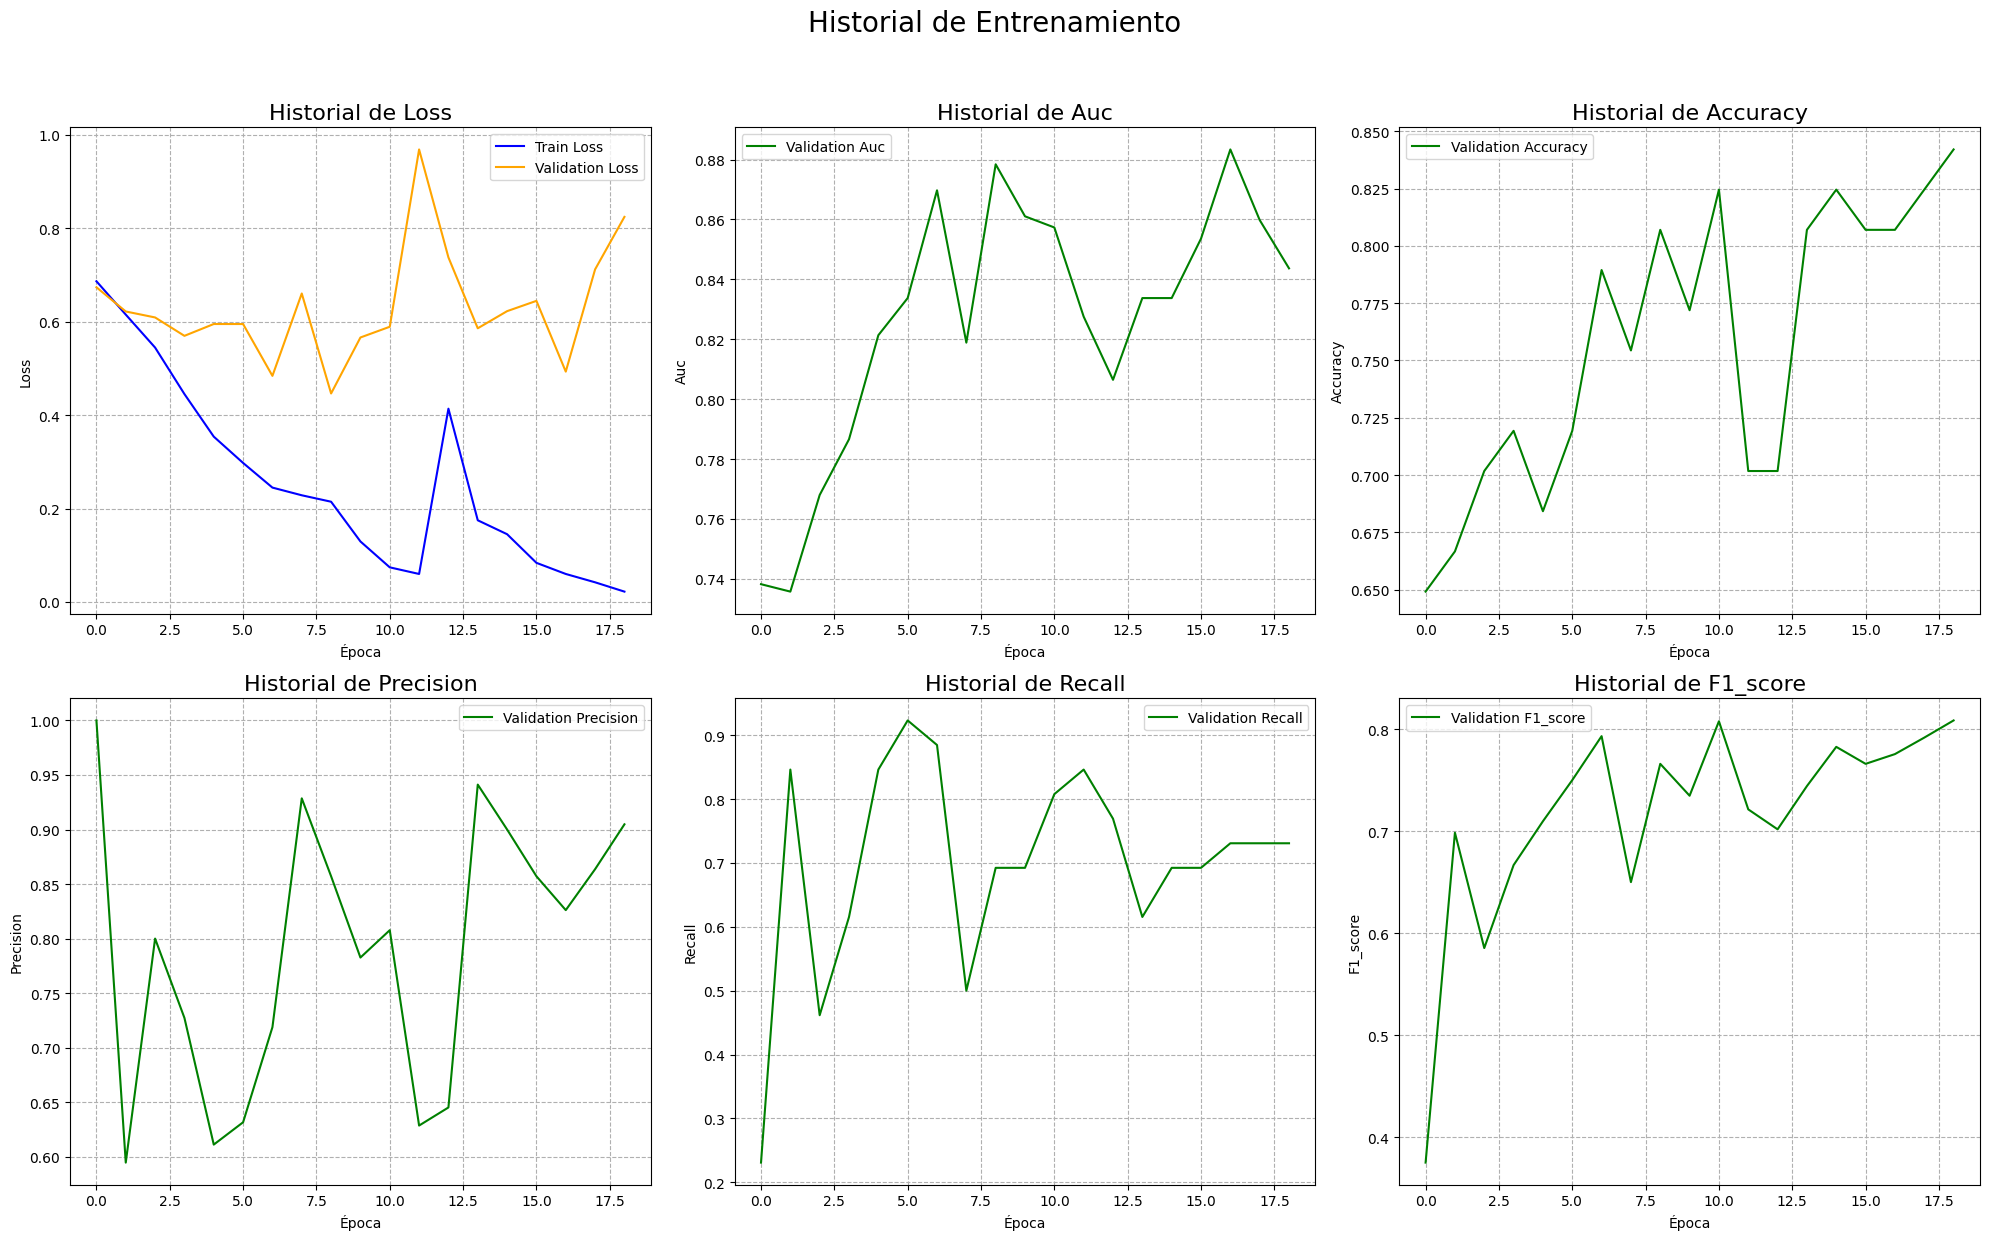

#### 2_classification_analysis

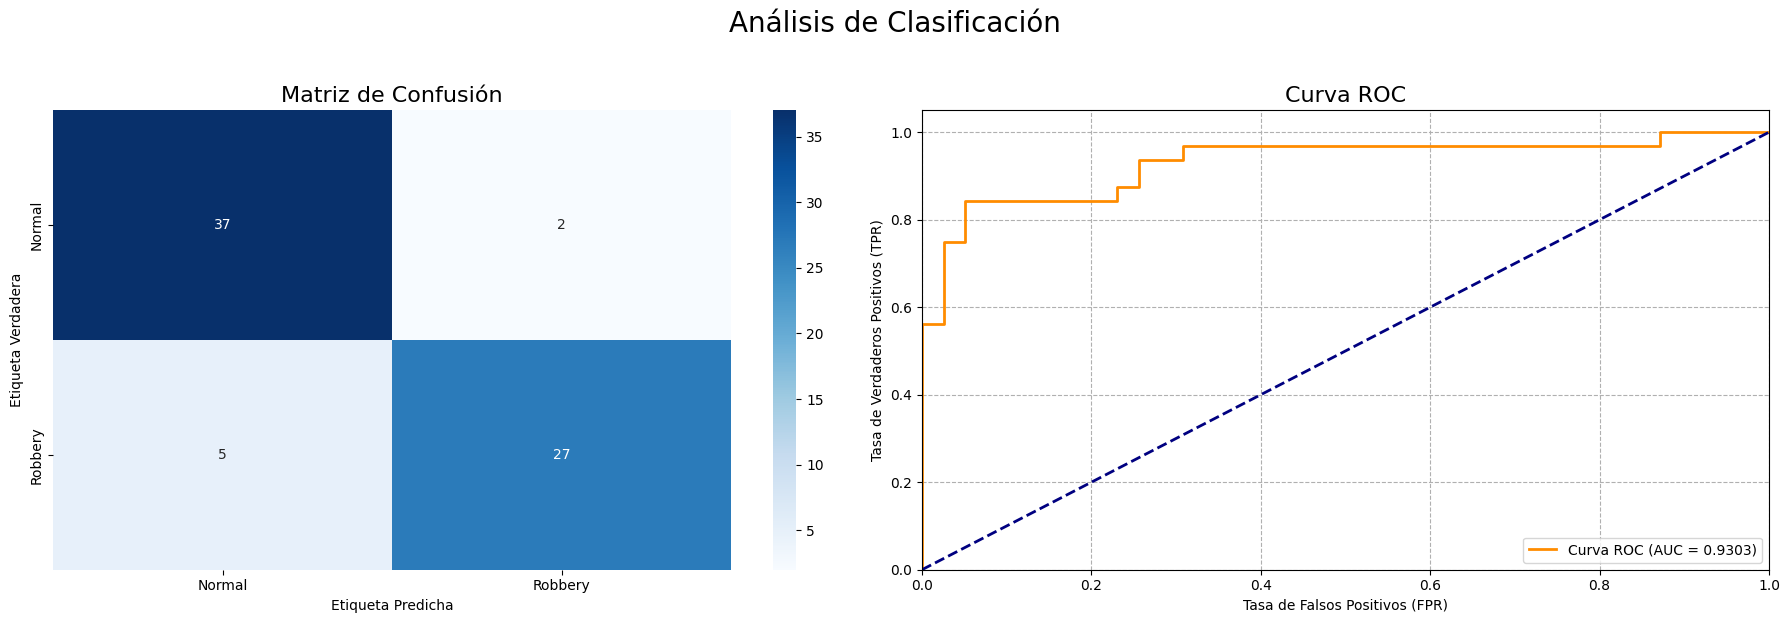

In [9]:
# Cargar gráficos guardados del experimento
plots_dir = BEST_EXP_DIR / 'results' / 'plots'

if plots_dir.exists():
    plot_files = list(plots_dir.glob('*.png'))
    
    if plot_files:
        display(Markdown("### Análisis Visual"))
        
        for plot_file in sorted(plot_files):
            display(Markdown(f"#### {plot_file.stem}"))
            display(Image(filename=str(plot_file), width=900))
            print()
    else:
        print("No se encontraron gráficos guardados.")
else:
    print("No existe el directorio de plots.")

## 6. Análisis de Predicciones

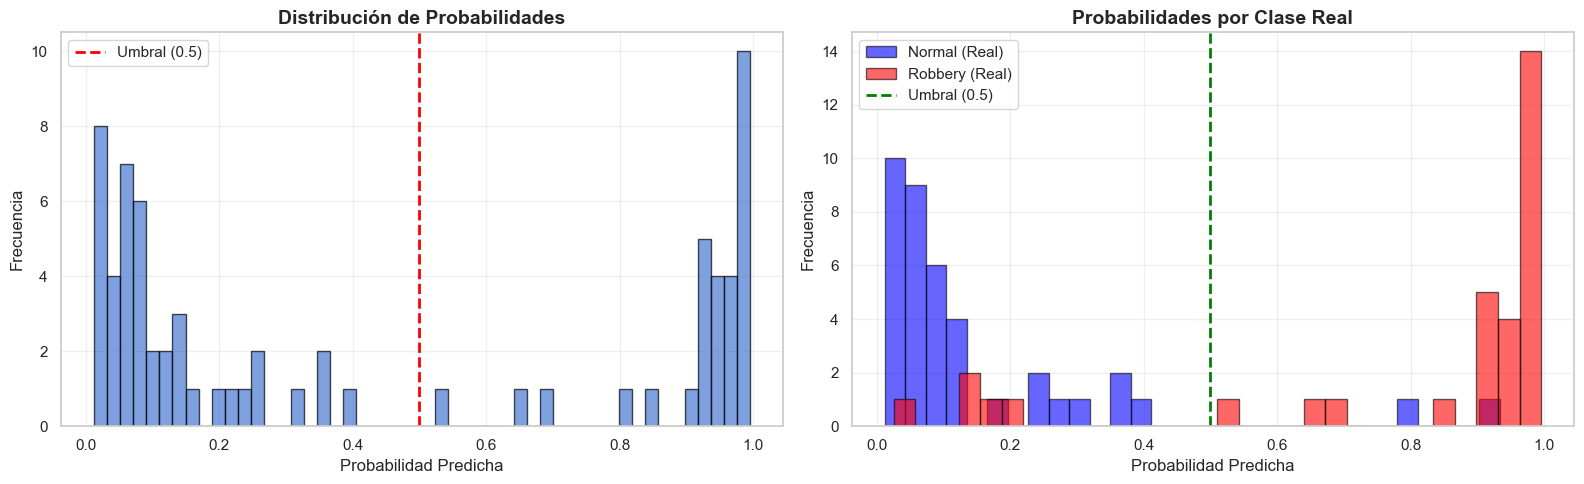

### Estadísticas de Probabilidades Predichas

,Clase Real,Media,Desv. Std,Min,Max
0,Normal,0.1507,0.1970,0.0116,0.9339
1,Robbery,0.7996,0.3057,0.0254,0.9959
2,General,0.4432,0.4095,0.0116,0.9959


In [10]:
if preds_path.exists():
    y_probs = np.array(predictions['probs'])
    
    # Distribución de probabilidades predichas
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # Histograma general
    axes[0].hist(y_probs, bins=50, edgecolor='black', alpha=0.7)
    axes[0].axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Umbral (0.5)')
    axes[0].set_xlabel('Probabilidad Predicha', fontsize=12)
    axes[0].set_ylabel('Frecuencia', fontsize=12)
    axes[0].set_title('Distribución de Probabilidades', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Distribución por clase real
    probs_normal = y_probs[np.array(y_true) == 0]
    probs_robbery = y_probs[np.array(y_true) == 1]
    
    axes[1].hist(probs_normal, bins=30, alpha=0.6, label='Normal (Real)', color='blue', edgecolor='black')
    axes[1].hist(probs_robbery, bins=30, alpha=0.6, label='Robbery (Real)', color='red', edgecolor='black')
    axes[1].axvline(x=0.5, color='green', linestyle='--', linewidth=2, label='Umbral (0.5)')
    axes[1].set_xlabel('Probabilidad Predicha', fontsize=12)
    axes[1].set_ylabel('Frecuencia', fontsize=12)
    axes[1].set_title('Probabilidades por Clase Real', fontsize=14, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Estadísticas de probabilidades
    display(Markdown("### Estadísticas de Probabilidades Predichas"))
    stats_data = {
        'Clase Real': ['Normal', 'Robbery', 'General'],
        'Media': [probs_normal.mean(), probs_robbery.mean(), y_probs.mean()],
        'Desv. Std': [probs_normal.std(), probs_robbery.std(), y_probs.std()],
        'Min': [probs_normal.min(), probs_robbery.min(), y_probs.min()],
        'Max': [probs_normal.max(), probs_robbery.max(), y_probs.max()]
    }
    df_stats = pd.DataFrame(stats_data)
    display(df_stats.style.format({
        'Media': '{:.4f}',
        'Desv. Std': '{:.4f}',
        'Min': '{:.4f}',
        'Max': '{:.4f}'
    }))

## 7. Empaquetado del Modelo

In [11]:
# Crear directorio de producción
results_dir = Path('../results')
results_dir.mkdir(parents=True, exist_ok=True)

display(Markdown("### Empaquetando Modelo Híbrido"))

# 1. Copiar modelo LSTM entrenado
model_src = BEST_EXP_DIR / 'results' / 'models' / 'best_lstm_model.pth'
model_dst = results_dir / 'lstm_model.pth'

if model_src.exists():
    import shutil
    shutil.copy2(model_src, model_dst)
    print(f"Modelo LSTM copiado a: {model_dst.resolve()}")
else:
    print("No se encontró el modelo LSTM entrenado.")

# 2. Determinar tipo de extractor usado
features_used = final_metrics.get('features_used', 'r3d')
feature_dim = best_hyperparams.get('input_size', 512)

print(f"\nTipo de extractor detectado: {features_used}")
print(f"   Dimensión de features: {feature_dim}")

# 3. Guardar configuración del modelo híbrido
model_config = {
    'experiment_name': BEST_EXPERIMENT,
    'hybrid_architecture': {
        'feature_extractor': {
            'type': 'r3d',
            'backbone': 'R3D-18 (3D ResNet-18)',
            'pretrained_weights': 'Kinetics-400',
            'output_dim': feature_dim,
            'clip_length': 16,
            'frame_size': [112, 112]
        },
        'classifier': {
            'type': 'LSTM',
            'input_size': feature_dim,
            'hidden_size': best_hyperparams.get('hidden_size'),
            'num_layers': best_hyperparams.get('num_layers'),
            'bidirectional': best_hyperparams.get('bidirectional'),
            'dropout_fc': best_hyperparams.get('dropout_fc')
        }
    },
    'training_config': {
        'lr': best_hyperparams.get('lr'),
        'weight_decay': best_hyperparams.get('weight_decay'),
        'batch_size': best_hyperparams.get('batch_size')
    },
    'performance_metrics': test_metrics,
    'class_names': CLASS_NAMES,
    'threshold': 0.5,
    'preprocessing': {
        'normalize_mean': [0.43216, 0.394666, 0.37645],
        'normalize_std': [0.22803, 0.22145, 0.216989],
        'resize': [112, 112]
    }
}

config_dst = results_dir / 'model_config.json'
with open(config_dst, 'w', encoding='utf-8') as f:
    json.dump(model_config, f, indent=4)
print(f"Configuración guardada en: {config_dst.resolve()}")

# 4. Copiar código fuente necesario
print("\nCopiando código fuente...")
src_dir = results_dir / 'src'
src_dir.mkdir(exist_ok=True)

lstm_src = Path('../src/models/lstm_classifier.py')
lstm_dst = src_dir / 'lstm_classifier.py'
if lstm_src.exists():
    shutil.copy2(lstm_src, lstm_dst)
    print(f"lstm_classifier.py copiado")

# 5. Crear script de inferencia end-to-end
inference_script = '''
import torch
import torch.nn as nn
import numpy as np
import json
import cv2
from pathlib import Path
from torchvision import transforms
from torchvision.models.video import r3d_18, R3D_18_Weights
from PIL import Image
try:
    from src.lstm_classifier import LSTMClassifier
except ImportError:
    import sys
    sys.path.append(str(Path(__file__).parent))
    from src.lstm_classifier import LSTMClassifier

class HybridRobberyDetector(nn.Module):
    """
    Modelo híbrido end-to-end para detección de robos.
    Combina R3D-18 (extractor de características) + LSTM (clasificador).
    """
    def __init__(self, config):
        super(HybridRobberyDetector, self).__init__()
        self.config = config
        
        # Feature Extractor: R3D-18 sin FC layer
        self.feature_extractor = self._build_feature_extractor()
        
        # Classifier: LSTM
        classifier_config = config['hybrid_architecture']['classifier']
        self.classifier = LSTMClassifier(
            input_size=classifier_config['input_size'],
            hidden_size=classifier_config['hidden_size'],
            num_layers=classifier_config['num_layers'],
            bidirectional=classifier_config['bidirectional'],
            dropout_fc=classifier_config['dropout_fc']
        )
        
        # Preprocessing
        preproc = config['preprocessing']
        self.transform = transforms.Compose([
            transforms.Resize(tuple(preproc['resize'])),
            transforms.ToTensor(),
            transforms.Normalize(mean=preproc['normalize_mean'], std=preproc['normalize_std'])
        ])
    
    def _build_feature_extractor(self):
        """Construye el extractor R3D-18 sin la capa FC."""
        weights = R3D_18_Weights.DEFAULT
        model = r3d_18(weights=weights)
        model.fc = nn.Identity()  # Eliminar fully connected layer
        
        # Congelar parámetros (opcional, para inferencia)
        for param in model.parameters():
            param.requires_grad = False
        
        return model
    
    def forward(self, clip_features):
        """
        Forward pass a través de LSTM.
        
        Args:
            clip_features: Tensor de shape (batch, n_clips, feature_dim)
        
        Returns:
            Probabilidad de robo (batch,)
        """
        return self.classifier(clip_features)
    
    def extract_features_from_clip(self, clip_path, clip_len=16):
        """
        Extrae features de un clip de video usando R3D-18.
        
        Args:
            clip_path: Ruta al archivo de video (.mp4)
            clip_len: Número de frames a extraer
        
        Returns:
            Tensor de features de shape (feature_dim,)
        """
        cap = cv2.VideoCapture(str(clip_path))
        frames = []
        
        for _ in range(clip_len):
            ret, frame = cap.read()
            if not ret:
                break
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = Image.fromarray(frame)
            frames.append(self.transform(frame))
        
        cap.release()
        
        # Repetir último frame si es necesario
        while len(frames) < clip_len:
            frames.append(frames[-1])
        
        # Shape: (1, 3, clip_len, H, W)
        clip_tensor = torch.stack(frames, dim=1).unsqueeze(0)
        
        with torch.no_grad():
            features = self.feature_extractor(clip_tensor)
        
        return features.squeeze()


class RobberyDetector:
    """
    Interfaz de alto nivel para detección de robos en videos.
    """
    def __init__(self, model_dir='results'):
        self.model_dir = Path(model_dir)
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
        # Cargar configuración
        with open(self.model_dir / 'model_config.json', 'r') as f:
            self.config = json.load(f)
        
        # Cargar modelo híbrido
        self.model = self._load_hybrid_model()
        self.threshold = self.config['threshold']
    
    def _load_hybrid_model(self):
        """Carga el modelo híbrido completo."""
        model = HybridRobberyDetector(self.config).to(self.device)
        
        # Cargar pesos de LSTM
        lstm_weights = torch.load(self.model_dir / 'lstm_model.pth', map_location=self.device)
        model.classifier.load_state_dict(lstm_weights)
        
        model.eval()
        return model
    
    def predict_from_features(self, features):
        """
        Predice a partir de features pre-extraídos.
        
        Args:
            features: numpy array of shape (n_clips, feature_dim)
        
        Returns:
            dict: {'class': str, 'probability': float, 'is_robbery': bool}
        """
        with torch.no_grad():
            features_tensor = torch.tensor(features, dtype=torch.float32).unsqueeze(0).to(self.device)
            output = self.model(features_tensor)
            prob = output.item()
        
        is_robbery = prob >= self.threshold
        class_name = self.config['class_names'][1] if is_robbery else self.config['class_names'][0]
        
        return {
            'class': class_name,
            'probability': prob,
            'is_robbery': is_robbery
        }
    
    def predict_from_video_clips(self, clip_paths):
        """
        Predice a partir de clips de video (extrae features automáticamente).
        
        Args:
            clip_paths: Lista de rutas a clips .mp4
        
        Returns:
            dict: {'class': str, 'probability': float, 'is_robbery': bool}
        """
        features_list = []
        
        for clip_path in clip_paths:
            feat = self.model.extract_features_from_clip(clip_path)
            features_list.append(feat.cpu().numpy())
        
        features = np.array(features_list)
        return self.predict_from_features(features)
    
    def get_model_info(self):
        """Retorna información del modelo."""
        return {
            'experiment': self.config['experiment_name'],
            'architecture': self.config['hybrid_architecture'],
            'metrics': self.config['performance_metrics']
        }


# Ejemplo de uso
if __name__ == "__main__":
    print("=" * 50)
    print("Robbery Detection - Hybrid Model")
    print("=" * 50)
    
    detector = RobberyDetector()
    info = detector.get_model_info()
    
    print(f"\\nExperimento: {info['experiment']}")
    print(f"Feature Extractor: {info['architecture']['feature_extractor']['backbone']}")
    print(f"Classifier: {info['architecture']['classifier']['type']}")
    print(f"\\nMétricas de Test:")
    for metric, value in info['metrics'].items():
        print(f"  {metric}: {value:.4f}")
    
    print("\\n" + "=" * 50)
    print("Ejemplo 1: Predicción desde features pre-extraídos")
    print("=" * 50)
    fake_features = np.random.randn(32, 512)
    result = detector.predict_from_features(fake_features)
    print(f"Predicción: {result['class']}")
    print(f"Probabilidad: {result['probability']:.4f}")
    print(f"Es robo: {result['is_robbery']}")
    
    print("\\n" + "=" * 50)
    print("Ejemplo 2: Predicción desde clips de video")
    print("=" * 50)
    print("# clip_paths = ['clip1.mp4', 'clip2.mp4', ...]")
    print("# result = detector.predict_from_video_clips(clip_paths)")
'''

inference_dst = results_dir / 'inference.py'
with open(inference_dst, 'w', encoding='utf-8') as f:
    f.write(inference_script)
print(f"Script de inferencia híbrida creado en: {inference_dst.resolve()}")

# 6. Crear README
readme_content = f'''
# Modelo Híbrido de Detección de Robos - {BEST_EXPERIMENT}

## Arquitectura del Modelo

Este es un modelo **híbrido end-to-end** que combina:

1. **Feature Extractor: R3D-18 (3D ResNet-18)**
   - Pre-entrenado en Kinetics-400
   - Sin capa fully connected (extrae features de {feature_dim} dimensiones)
   - Input: Clips de video (16 frames de 112x112)
   - Output: Vector de features por clip

2. **Classifier: LSTM Bidireccional**
   - Input Size: {best_hyperparams.get('input_size', 512)}
   - Hidden Size: {best_hyperparams.get('hidden_size')}
   - Num Layers: {best_hyperparams.get('num_layers')}
   - Bidirectional: {best_hyperparams.get('bidirectional')}
   - Dropout: {best_hyperparams.get('dropout_fc')}

**Pipeline completo:** Video -> R3D-18 -> Features -> LSTM -> Probabilidad de Robo

## Métricas de Rendimiento (Test Set)

- **Accuracy:** {test_metrics.get('accuracy', 0):.4f}
- **Precision:** {test_metrics.get('precision', 0):.4f}
- **Recall:** {test_metrics.get('recall', 0):.4f}
- **F1-Score:** {test_metrics.get('f1_score', 0):.4f}
- **AUC-ROC:** {test_metrics.get('auc', 0):.4f}

## Uso

### Opción 1: Predicción desde features pre-extraídos

```python
from inference import RobberyDetector
import numpy as np

# Inicializar detector
detector = RobberyDetector()

# Features pre-extraídos (n_clips, {feature_dim})
features = np.load('video_features.npy')
result = detector.predict_from_features(features)

print(f"Clase: {{result['class']}}")
print(f"Probabilidad: {{result['probability']:.4f}}")
print(f"Es robo: {{result['is_robbery']}}")
```

### Opción 2: Predicción end-to-end desde clips de video

```python
from inference import RobberyDetector

# Inicializar detector
detector = RobberyDetector()

# Lista de clips del video
clip_paths = ['clip_001.mp4', 'clip_002.mp4', 'clip_003.mp4', ...]
result = detector.predict_from_video_clips(clip_paths)

print(f"Clase: {{result['class']}}")
print(f"Probabilidad: {{result['probability']:.4f}}")
```

## Estructura de Archivos

```
results/
├── lstm_model.pth          # Pesos del clasificador LSTM
├── model_config.json       # Configuración completa del modelo híbrido
├── inference.py            # Script de inferencia end-to-end
├── src/
│   └── lstm_classifier.py  # Definición de la arquitectura LSTM
└── README.md               # Esta documentación
```

## Detalles Técnicos

### Preprocesamiento de Video
- **Resize:** 112x112 píxeles
- **Normalización:** 
  - Mean: [0.43216, 0.394666, 0.37645]
  - Std: [0.22803, 0.22145, 0.216989]
- **Clip length:** 16 frames consecutivos

### Modelo R3D-18
- Pre-entrenado en Kinetics-400
- Arquitectura: 3D ResNet con 18 capas
- Features extraídos: Última capa antes de FC (512-d)

### Clasificación
- **Umbral:** 0.5 (probabilidad >= 0.5 -> Robbery)
- **Clases:** Normal, Robbery

## Información del Experimento

- **Experimento:** {BEST_EXPERIMENT}
- **Features usados:** {final_metrics.get('features_used', 'N/A')}
- **Fecha de creación:** {pd.Timestamp.now().strftime('%Y-%m-%d')}

## Notas

- El modelo R3D-18 se descarga automáticamente la primera vez que se ejecuta
- Para GPU: asegúrate de tener CUDA instalado correctamente
- El modelo híbrido permite tanto inferencia rápida (con features pre-extraídos) como inferencia end-to-end (directamente desde videos)
'''

readme_dst = results_dir / 'README.md'
with open(readme_dst, 'w', encoding='utf-8') as f:
    f.write(readme_content)
print(f"README creado en: {readme_dst.resolve()}")

# 7. Guardar modelo híbrido completo en un solo archivo (opcional)
print("\nGuardando modelo híbrido completo...")

try:
    from src.models.lstm_classifier import LSTMClassifier
    from torchvision.models.video import r3d_18, R3D_18_Weights
    import torch.nn as nn
    
    # Crear modelo completo en modo eval
    class HybridModel(nn.Module):
        def __init__(self, lstm_config):
            super().__init__()
            # R3D-18 feature extractor
            weights = R3D_18_Weights.DEFAULT
            self.feature_extractor = r3d_18(weights=weights)
            self.feature_extractor.fc = nn.Identity()
            
            # LSTM classifier
            self.classifier = LSTMClassifier(**lstm_config)
        
        def forward(self, clip_features):
            return self.classifier(clip_features)
    
    # Instanciar y cargar pesos
    hybrid_model = HybridModel({
        'input_size': best_hyperparams.get('input_size', 512),
        'hidden_size': best_hyperparams.get('hidden_size'),
        'num_layers': best_hyperparams.get('num_layers'),
        'bidirectional': best_hyperparams.get('bidirectional'),
        'dropout_fc': best_hyperparams.get('dropout_fc')
    })
    
    # Cargar pesos del LSTM
    lstm_state = torch.load(model_src, map_location='cpu')
    hybrid_model.classifier.load_state_dict(lstm_state)
    hybrid_model.eval()
    
    # Guardar modelo completo
    hybrid_dst = results_dir / 'hybrid_model_complete.pth'
    torch.save({
        'hybrid_state_dict': hybrid_model.state_dict(),
        'config': model_config,
        'class_names': CLASS_NAMES
    }, hybrid_dst)
    
    print(f"Modelo híbrido completo guardado en: {hybrid_dst.resolve()}")
except Exception as e:
    print(f"No se pudo crear modelo híbrido completo: {e}")

display(Markdown(f"""
### Empaquetado Completo del Modelo Híbrido

**Directorio de producción:** `{results_dir.resolve()}`

**Archivos generados:**
1. `lstm_model.pth` - Pesos del clasificador LSTM entrenado
2. `model_config.json` - Configuración completa del modelo híbrido
3. `inference.py` - Script de inferencia end-to-end (R3D-18 + LSTM)
4. `src/lstm_classifier.py` - Definición de la arquitectura LSTM
5. `hybrid_model_complete.pth` - Modelo completo empaquetado (R3D + LSTM)
6. `README.md` - Documentación completa

**Modos de uso:**

**1. Desde features pre-extraídos (rápido):**
```python
from results.inference import RobberyDetector
detector = RobberyDetector()
result = detector.predict_from_features(features)  # features: (n_clips, 512)
```

**2. End-to-end desde clips de video (completo):**
```python
from results.inference import RobberyDetector
detector = RobberyDetector()
clip_paths = ['clip1.mp4', 'clip2.mp4', ...]
result = detector.predict_from_video_clips(clip_paths)
```

**Arquitectura:**
- **Feature Extractor:** R3D-18 pre-entrenado (Kinetics-400)
- **Classifier:** LSTM Bidireccional ({best_hyperparams.get('num_layers')} capas, {best_hyperparams.get('hidden_size')} hidden units)
- **Pipeline:** Video (16 frames) -> R3D-18 -> Features ({feature_dim}-d) -> LSTM -> Probabilidad
"""))

### Empaquetando Modelo Híbrido

Modelo LSTM copiado a: D:\Dataset\results\lstm_model.pth

Tipo de extractor detectado: ..\experiments\exp_12\processed_data\features
   Dimensión de features: 512
Configuración guardada en: D:\Dataset\results\model_config.json

Copiando código fuente...
lstm_classifier.py copiado
Script de inferencia híbrida creado en: D:\Dataset\results\inference.py
README creado en: D:\Dataset\results\README.md

Guardando modelo híbrido completo...
Modelo híbrido completo guardado en: D:\Dataset\results\hybrid_model_complete.pth



### Empaquetado Completo del Modelo Híbrido

**Directorio de producción:** `D:\Dataset\results`

**Archivos generados:**
1. `lstm_model.pth` - Pesos del clasificador LSTM entrenado
2. `model_config.json` - Configuración completa del modelo híbrido
3. `inference.py` - Script de inferencia end-to-end (R3D-18 + LSTM)
4. `src/lstm_classifier.py` - Definición de la arquitectura LSTM
5. `hybrid_model_complete.pth` - Modelo completo empaquetado (R3D + LSTM)
6. `README.md` - Documentación completa

**Modos de uso:**

**1. Desde features pre-extraídos (rápido):**
```python
from results.inference import RobberyDetector
detector = RobberyDetector()
result = detector.predict_from_features(features)  # features: (n_clips, 512)
```

**2. End-to-end desde clips de video (completo):**
```python
from results.inference import RobberyDetector
detector = RobberyDetector()
clip_paths = ['clip1.mp4', 'clip2.mp4', ...]
result = detector.predict_from_video_clips(clip_paths)
```

**Arquitectura:**
- **Feature Extractor:** R3D-18 pre-entrenado (Kinetics-400)
- **Classifier:** LSTM Bidireccional (1 capas, 256 hidden units)
- **Pipeline:** Video (16 frames) -> R3D-18 -> Features (512-d) -> LSTM -> Probabilidad


## 8. Resumen Final

In [12]:
display(Markdown(f"""
# Resumen del Mejor Modelo Híbrido

## Identificación
- **Experimento:** {BEST_EXPERIMENT}
- **Directorio:** `{BEST_EXP_DIR.resolve()}`

## Arquitectura Híbrida

### Feature Extractor (R3D-18)
- **Tipo:** 3D ResNet-18
- **Pre-entrenamiento:** Kinetics-400
- **Output Dimension:** {feature_dim}
- **Input:** Clips de 16 frames (112x112 px)

### Classifier (LSTM)
- **Tipo:** LSTM Bidireccional
- **Input Size:** {best_hyperparams.get('input_size', 512)}
- **Hidden Size:** {best_hyperparams.get('hidden_size')}
- **Num Layers:** {best_hyperparams.get('num_layers')}
- **Bidireccional:** {best_hyperparams.get('bidirectional')}
- **Dropout:** {best_hyperparams.get('dropout_fc')}

## Entrenamiento
- **Learning Rate:** {best_hyperparams.get('lr'):.6f}
- **Weight Decay:** {best_hyperparams.get('weight_decay'):.6f}
- **Batch Size:** {best_hyperparams.get('batch_size')}
- **Mejor Epoch:** {final_metrics.get('best_epoch', 'N/A')}
- **Val Loss (mejor):** {final_metrics.get('best_validation_loss', 'N/A'):.6f}
- **Val AUC (mejor):** {final_metrics.get('best_validation_auc', 'N/A'):.4f}

## Rendimiento en Test
- **Accuracy:** {test_metrics.get('accuracy', 0):.4f}
- **Precision:** {test_metrics.get('precision', 0):.4f}
- **Recall:** {test_metrics.get('recall', 0):.4f}
- **F1-Score:** {test_metrics.get('f1_score', 0):.4f}
- **AUC-ROC:** {test_metrics.get('auc', 0):.4f}

## Métricas por Clase (Test)
### Normal
- Precision: {report_dict['Normal']['precision']:.4f}
- Recall: {report_dict['Normal']['recall']:.4f}
- F1-Score: {report_dict['Normal']['f1-score']:.4f}

### Robbery
- Precision: {report_dict['Robbery']['precision']:.4f}
- Recall: {report_dict['Robbery']['recall']:.4f}
- F1-Score: {report_dict['Robbery']['f1-score']:.4f}

## Pipeline Completo
**Video -> Clips (16 frames) -> R3D-18 -> Features ({feature_dim}-d) -> LSTM -> Probabilidad de Robo**

---

**Fecha de análisis:** {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}
"""))


# Resumen del Mejor Modelo Híbrido

## Identificación
- **Experimento:** exp_12
- **Directorio:** `D:\Dataset\experiments\exp_12`

## Arquitectura Híbrida

### Feature Extractor (R3D-18)
- **Tipo:** 3D ResNet-18
- **Pre-entrenamiento:** Kinetics-400
- **Output Dimension:** 512
- **Input:** Clips de 16 frames (112x112 px)

### Classifier (LSTM)
- **Tipo:** LSTM Bidireccional
- **Input Size:** 512
- **Hidden Size:** 256
- **Num Layers:** 1
- **Bidireccional:** True
- **Dropout:** 0.5947547746402069

## Entrenamiento
- **Learning Rate:** 0.000738
- **Weight Decay:** 0.000122
- **Batch Size:** 32
- **Mejor Epoch:** 9
- **Val Loss (mejor):** 0.446287
- **Val AUC (mejor):** 0.8784

## Rendimiento en Test
- **Accuracy:** 0.9014
- **Precision:** 0.9310
- **Recall:** 0.8438
- **F1-Score:** 0.8852
- **AUC-ROC:** 0.9303

## Métricas por Clase (Test)
### Normal
- Precision: 0.8810
- Recall: 0.9487
- F1-Score: 0.9136

### Robbery
- Precision: 0.9310
- Recall: 0.8438
- F1-Score: 0.8852

## Pipeline Completo
**Video -> Clips (16 frames) -> R3D-18 -> Features (512-d) -> LSTM -> Probabilidad de Robo**

---

**Fecha de análisis:** 2026-01-19 00:06:53
